In [12]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

import numpy as np
import pandas as pd
import seaborn as sns

# Supervised learning - Classification

### Data quality checks and EDA

In [ ]:
# load the data
iris_dataset = load_iris()

In [ ]:
# understand the data
print(
    iris_dataset.keys(),

    iris_dataset['DESCR'],

    iris_dataset['feature_names']
)

In [ ]:
print(
    iris_dataset['data'],

    iris_dataset['data'].shape,

    iris_dataset['target'],

    iris_dataset['target_names'],

    iris_dataset['target'].shape
)

In [ ]:
# Null values check
print(
    np.isnan(iris_dataset['data']),

    iris_dataset['data'][np.isnan(iris_dataset['data'])],

    np.isnan(iris_dataset['target'])
)

In [ ]:
# Summary statistics
tmp_df = pd.DataFrame(iris_dataset['data'])

tmp_df.columns = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

tmp_df.describe()

In [ ]:
# Column-wise stats
# tmp_df
tmp_df.mean()

In [ ]:
# Univariate analysis
tmp_df.hist(column='sepal length (cm)')

In [ ]:
# Bivariate analysis
tmp_df.plot.scatter(x='sepal length (cm)', y='sepal width (cm)', title="Sepal Length vs Width")

In [ ]:
sns.pairplot(data=tmp_df)

In [ ]:
tmp_df.corr()

### Let's start with the most basic model - KNN classifier

<img src="/Users/manojkumar_rajendran/Desktop/MR/Technology_Learning/TutorNotes/Data_Science/Classical_ML/images/working_of_knn.png" alt="sample" width="1000"/>

### Model training

In [ ]:
# training, testing and hold-out set

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    tmp_df, iris_dataset['target'], random_state=0
) # random_state of 0 ensures deterministic sampling

In [ ]:
X_train.shape

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)

In [ ]:
knn.fit(X_train, y_train)

In [ ]:
y_pred = knn.predict(X_test)

In [ ]:
y_pred

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Predicted:", y_pred[:10])
print("Actual   :", y_test[:10])

### Model prediction

In [ ]:
y_pred = knn.predict(X_test)

### Model evaluation

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Predicted:", y_pred[:10])
print("Actual   :", y_test[:10])

### Visualize the decision boundary

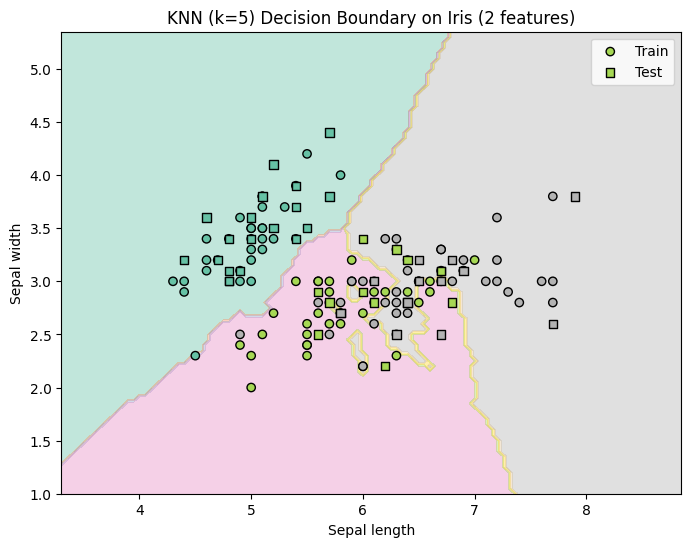

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# 1. Load dataset (take only first 2 features for 2D plot)
iris = load_iris()
X = iris.data[:, :2]   # sepal length & sepal width
y = iris.target

# 2. Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Train KNN (k=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 4. Create a mesh grid for decision boundary
h = 0.05  # step size in the mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 5. Predict on mesh
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 6. Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.Set2)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
            marker='o', edgecolor='k', cmap=plt.cm.Set2, label="Train")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, 
            marker='s', edgecolor='k', cmap=plt.cm.Set2, label="Test")

plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("KNN (k=5) Decision Boundary on Iris (2 features)")
plt.legend()
plt.show()

# Insights & Inferences of KNN algorithm

##### Advantages of KNN :

Simple to understand and implement. <br>
Few hyperparameters. <br>
Works well with small datasets. <br>

##### Limitations of KNN :

Slow with large datasets (computes distance for all points). <br>
Curse of dimensionality (More number of features). <br>
Entire training data is memorized. <br>
Sensitive to irrelevant or unscaled features. <br>
Choice of k is critical: <br>
    Too small → noisy predictions and may lead to overfitting.  <br>
    Too large → overly smooth predictions. <br>

##### Question to ponder : Do you need to scale the input features before applying KNN ?

Yes. As KNN relies on distance metrics, Scaling (especially for numerical features) ensures 
all features contribute equally to the distance calculation.